## [Part 1] 비즈니스 데이터 구조 이해 및 가상 데이터를 활용한 분석 설계

In [23]:
import pandas as pd
import numpy as np
import random
import sqlite3
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime,timedelta
import platform

#운영체제별 폰트
if platform.system() =='Darwin' : plt.rc('font',family='AppleGothic')
elif platform.system() =='Windows' : plt.rc('font',family='Malgun Gothic')
else : plt.rc('font',family='DejaVu Sans')
plt.rcParams['axes.unicode_minus']=False

#임시 데이터베이스 생성
conn=sqlite3.connect(':memory:')

#공공데이터포털 API
AUTH_KEY="002d14c0f2b78344ad5e100d8ba4d7140142c4782899795912c6aee594e03097"

In [24]:
def fetch_and_load_data(key):
    #공공데이터포털 API
    endpoint="https://api.odcloud.kr/api/15083033/v1/uddi:c7049f5a-d95e-4143-be96-b4d3c16130ee"
    params={'page' : 1, 'perPage' :100, 'serviceKey': key}

    try:
        res=requests.get(endpoint,params=params,timeout=5)
        if res.status_code==200:
            data=res.json().get('data',[])
            if not data:raise Exception("No Data")
            df_cafes=pd.DataFrame(data)
            df_cafes=df_cafes.iloc[:,:3]
            df_cafes.columns=['bizesId','bizesNm','rdnmAdr']
            print(f"✅ API 데이터 수집 성공({len(df_cafes)}개)")

        else:
            raise Exception("API Key or Server Error")

    except Exception as e:
        print(f"❌ API 대신 가상 매장 데이터를 생성 : (사유 : {e})")
        df_cafes=pd.DataFrame({
            'bizesId' : [f"CAFE_{i:03d}" for i in range(1,21)],
            'bizesNm' : ['스타벅스 강남점','투썸플레이스','이디야','블루보틀 역삼','폴바셋']*4,
            'rdnmAdr' : [f"강난구 테헤란로 {i}길" for i in range(1,21)]
        })
        print("API 대신 가상 매장 데이터를 생성했습니다.")

    #가상의 주문 데이터 (매장,금액,시간) 
    #공공 데이터에는 위의 데이터가 없어서 가상으로 생성 
    num_users=500
    u_ids=[f"U_{i:04d}" for i in range(1,num_users+1)]
    channels=['Instagram','Google_Ads','YouTube','Organic']
    df_users=pd.DataFrame({
        'user_id':u_ids,
        'signup_date':[datetime(2025,1,1)+timedelta(days=random.randint(0,100))for _ in range(num_users)],
        'channel' : [random.choice(channels) for _ in range(num_users)]
    })

    orders=[]
    cafe_ids=df_cafes['bizesId'].tolist()
    for _ in range(7000):
        uid=random.choice(u_ids)
        sid=random.choice(cafe_ids)
        sdt=pd.to_datetime(df_users.loc[df_users['user_id']==uid,'signup_date'].values[0])
        sdt=pd.to_datetime(sdt)
        odt=sdt+timedelta(days=random.randint(0,180),hours=random.randint(7,14))
        orders.append([uid,sid,odt,random.choice([4500,5500,12000,15000])])

    df_orders=pd.DataFrame(orders,columns=['user_id','store_id','order_at','amount'])

    df_cafes.to_sql('raw_cafes',conn,index=False,if_exists='replace')
    df_users.to_sql('raw_users',conn,index=False,if_exists='replace')
    df_orders.to_sql('raw_orders',conn,index=False,if_exists='replace')
    return "데이터 적재 완료"

print(fetch_and_load_data(AUTH_KEY))

✅ API 데이터 수집 성공(100개)
데이터 적재 완료


In [25]:
query_retention="""
With user_first_order AS(
    SELECT user_id,MIN(order_at) as first_order
    FROM raw_orders
    GROUP BY user_id
),
cohort_base AS(
    SELECT
        o.user_id,
        strftime('%Y-%m', f.first_order) as cohort_month,
        CAST(strftime('%Y', f.first_order) AS INT) as first_year,
        CAST(strftime('%m', f.first_order) AS INT) as first_month,
        CAST(strftime('%Y', o.order_at) AS INT) as order_year,
        CAST(strftime('%m', o.order_at) AS INT) as order_month
    FROM raw_orders o
    JOIN user_first_order f ON o.user_id=f.user_id
)

SELECT
    cohort_month,
    (order_year - first_year) * 12 + (order_month - first_month) as month_dist,
    COUNT(DISTINCT user_id) as user_cnt
FROM cohort_base
GROUP BY 1,2
ORDER BY 1,2
"""

mart_retention=pd.read_sql_query(query_retention,conn)

query_roas="""
SELECT
    u.channel,
    COUNT(DISTINCT u.user_id) as new_users,
    COALESCE(SUM(o.amount),0) as total_revenue
FROM raw_users u
LEFT JOIN raw_orders o ON u.user_id=o.user_id
GROUP BY 1
"""

mart_marketing=pd.read_sql_query(query_roas,conn)
print("SQL 데이터 마트 생성 완료")

SQL 데이터 마트 생성 완료


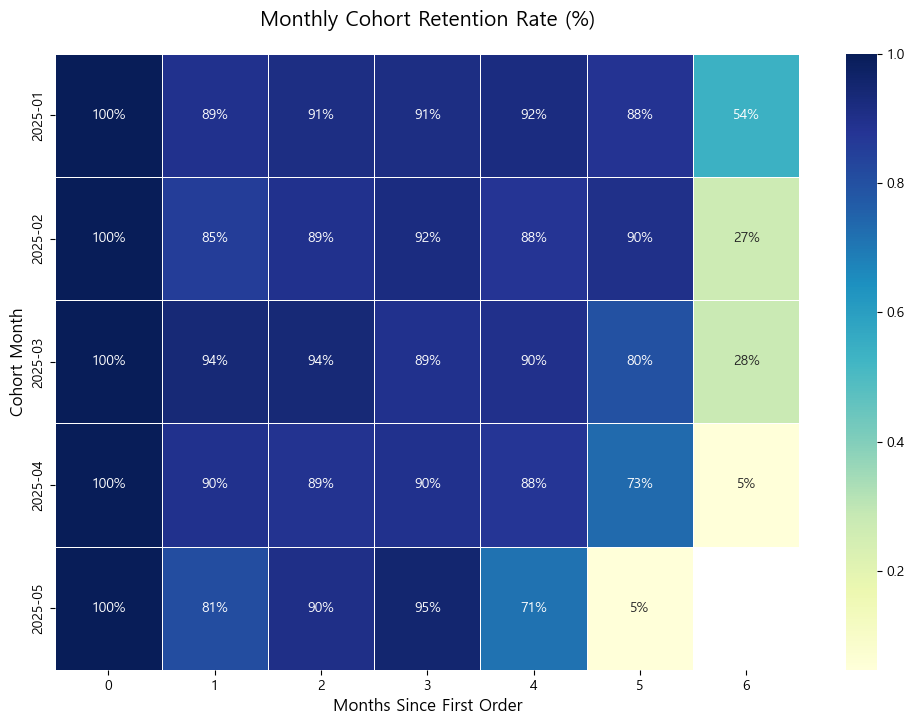

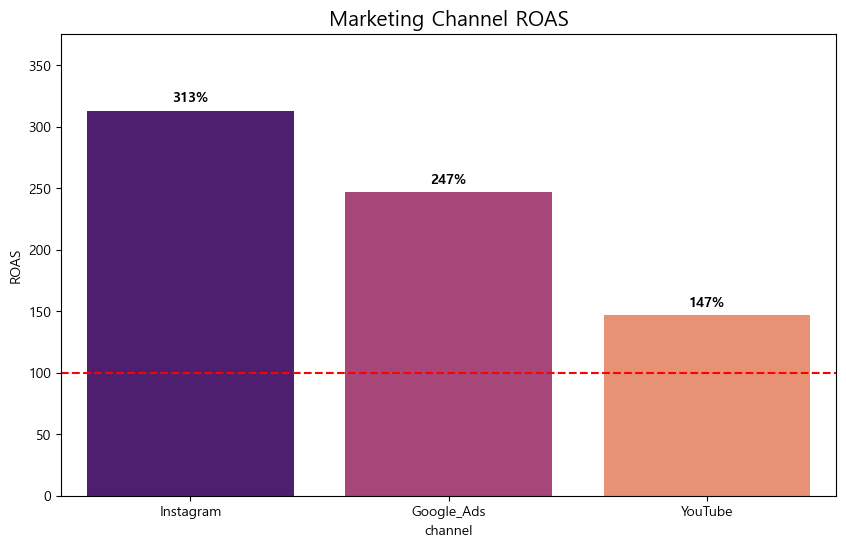


### 데이터 마케팅 효율 ###


,channel,total_revenue,spend,ROAS
1,Instagram,15656500,5000000,313.130000
0,Google_Ads,17297500,7000000,247.107143
3,YouTube,14672000,10000000,146.720000


In [27]:
mart_retention['month_dist']=mart_retention['month_dist'].astype(int)
mart_retention['cohort_month']=mart_retention['cohort_month'].astype(str)

retention_pivot=mart_retention.pivot(index='cohort_month',columns='month_dist',values='user_cnt')

retention_rate=retention_pivot.divide(retention_pivot.iloc[:,0],axis=0)

plt.figure(figsize=(12,8))
sns.heatmap(retention_rate,
            annot=True,
            fmt='.0%',
            cmap='YlGnBu',
            linewidths=.5)

plt.title('Monthly Cohort Retention Rate (%)',fontsize=15,pad=20)
plt.xlabel('Months Since First Order',fontsize=12)
plt.ylabel('Cohort Month',fontsize=12)
plt.show()

costs = {
    'Instagram': 5000000, 
    'Google_Ads': 7000000, 
    'YouTube': 10000000, 
    'Organic': 1
}
mart_marketing['spend'] = mart_marketing['channel'].map(costs)
mart_marketing['ROAS'] = (mart_marketing['total_revenue'] / mart_marketing['spend']) * 100

paid_marketing = mart_marketing[mart_marketing['channel'] != 'Organic'].copy()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=paid_marketing.sort_values('ROAS', ascending=False), 
                 x='channel', y='ROAS', hue='channel', palette='magma', legend=False)

# 막대 상단 수치 표기
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.axhline(100, color='red', linestyle='--', label='Break-even (100%)')
plt.ylim(0, max(paid_marketing['ROAS'].max() * 1.2, 120)) 
plt.title('Marketing Channel ROAS', fontsize=15)
plt.show()

print("\n" + "="*50)
print("### 데이터 마케팅 효율 ###")
print("="*50)
display(paid_marketing[['channel', 'total_revenue', 'spend', 'ROAS']].sort_values('ROAS', ascending=False))

## [Part2] 실제 이커머스(Olist) 데이터 분석

In [28]:
# Kaggle API를 활용해 실제 이커머스(Olist) 데이터를 로컬 환경에 구축
!pip install kaggle --upgrade
!kaggle datasets download -d olistbr/brazilian-ecommerce

import zipfile
import os
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import random

# 다운로드된 압축파일 해제 
zip_file = 'brazilian-ecommerce.zip'
if os.path.exists(zip_file):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('olist_data')
    print("✅ 데이터셋 준비 완료: 'olist_data' 폴더 확인")
else:
    print("❌ 파일 확인 필요: API 인증 또는 다운로드 상태 체크")

conn = sqlite3.connect(':memory:')

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
brazilian-ecommerce.zip: Skipping, found more recently modified local copy (use --force to force download)
✅ 데이터셋 준비 완료: 'olist_data' 폴더 확인


In [29]:
# 데이터셋을 로드 및 SQL 적재
try:
    df_orders = pd.read_csv('olist_data/olist_orders_dataset.csv')
    df_customers = pd.read_csv('olist_data/olist_customers_dataset.csv')
    df_payments = pd.read_csv('olist_data/olist_order_payments_dataset.csv')

    df_orders.to_sql('raw_orders', conn, index=False, if_exists='replace')
    df_customers.to_sql('raw_customers', conn, index=False, if_exists='replace')
    df_payments.to_sql('raw_payments', conn, index=False, if_exists='replace')

    print("✅ 분석용 데이터 SQL 적재 성공!")

except FileNotFoundError:
    print("❌ 오류: 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
except Exception as e:
    print(f"❌ 예상치 못한 오류 발생: (사유 : {e})")

✅ 분석용 데이터 SQL 적재 성공!


In [30]:
query_retention = """
WITH user_base AS (
    -- 주문 정보와 고객 고유 식별자(unique_id) 매핑
    SELECT 
        c.customer_unique_id AS user_id,
        o.order_purchase_timestamp AS order_at
    FROM raw_orders o
    JOIN raw_customers c ON o.customer_id = c.customer_id
),
user_first_order AS (
    SELECT user_id, MIN(order_at) as first_dt
    FROM user_base
    GROUP BY user_id
),
cohort_base AS (
    SELECT
        b.user_id,
        strftime('%Y-%m', f.first_dt) as cohort_month,
        CAST(strftime('%Y', f.first_dt) AS INT) as first_year,
        CAST(strftime('%m', f.first_dt) AS INT) as first_month,
        CAST(strftime('%Y', b.order_at) AS INT) as order_year,
        CAST(strftime('%m', b.order_at) AS INT) as order_month
    FROM user_base b
    JOIN user_first_order f ON b.user_id = f.user_id
)
SELECT
    cohort_month,
    (order_year - first_year) * 12 + (order_month - first_month) as month_dist,
    COUNT(DISTINCT user_id) as user_cnt
FROM cohort_base
WHERE month_dist >= 0
GROUP BY 1, 2
ORDER BY 1, 2
"""

mart_retention = pd.read_sql_query(query_retention, conn)

# 주문별 결제 데이터 합산
df_revenue = df_payments.groupby('order_id')['payment_value'].sum().reset_index()
df_revenue.to_sql('order_rev', conn, index=False, if_exists='replace')

# 분석용 가상 마케팅 채널 할당
channels = ['Instagram', 'Google_Ads', 'YouTube', 'Organic']
df_revenue['channel'] = [random.choice(channels) for _ in range(len(df_revenue))]
df_revenue.to_sql('mart_mkt_rev', conn, index=False, if_exists='replace')

query_roas = """
SELECT 
    channel,
    SUM(payment_value) as total_rev
FROM mart_mkt_rev
GROUP BY 1
"""
mart_roas = pd.read_sql_query(query_roas, conn)


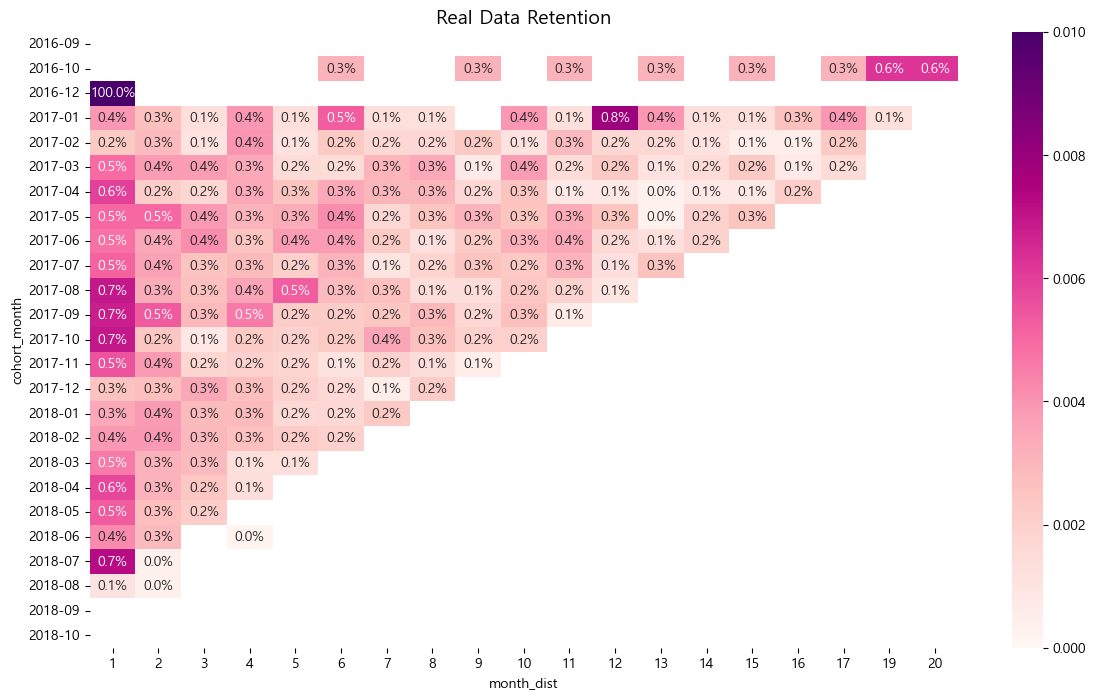

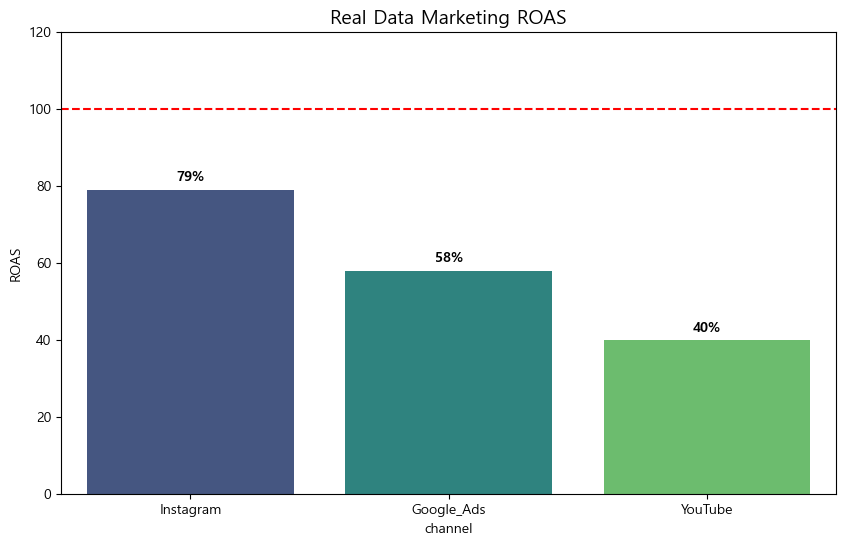


### 마케팅 효율 ###


,channel,total_rev,spend,ROAS
1,Instagram,3950374.28,5000000,79.007486
0,Google_Ads,4053146.68,7000000,57.902095
3,YouTube,3987758.14,10000000,39.877581


In [36]:
mart_retention['month_dist'] = mart_retention['month_dist'].astype(int)
mart_retention['cohort_month'] = mart_retention['cohort_month'].astype(str)

retention_pivot = mart_retention.pivot(index='cohort_month', columns='month_dist', values='user_cnt')
retention_rate = retention_pivot.divide(retention_pivot.iloc[:, 0], axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(retention_rate.iloc[:, 1:], annot=True, fmt='.1%', cmap='RdPu', vmin=0, vmax=0.01)
plt.title('Real Data Retention', fontsize=14)
plt.show()

costs = {'Instagram': 5000000, 'Google_Ads': 7000000, 'YouTube': 10000000, 'Organic': 1}
mart_roas['spend'] = mart_roas['channel'].map(costs)
mart_roas['ROAS'] = (mart_roas['total_rev'] / mart_roas['spend']) * 100

paid_marketing = mart_roas[mart_roas['channel'] != 'Organic'].copy()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=paid_marketing.sort_values('ROAS', ascending=False),
                 x='channel', y='ROAS', hue='channel', palette='viridis', legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.axhline(100, color='red', linestyle='--', label='BEP(100%)')
plt.ylim(0, max(paid_marketing['ROAS'].max() * 1.2, 120))
plt.title('Real Data Marketing ROAS', fontsize=14)
plt.show()

print("\n" + "="*50)
print("### 마케팅 효율 ###")
print("="*50)
# Part 2의 원본 컬럼명인 total_rev를 사용하여 출력
display(paid_marketing[['channel', 'total_rev', 'spend', 'ROAS']].sort_values('ROAS', ascending=False))